In [1]:
import jax
# JAX truncates float64 to float32 unless this is set.  Enable it before any
# array is created (see Remark 1 of the README).
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np

import pyproj
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 20

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

from OkadaJAX import OkadaWrapper
okada = OkadaWrapper()

/fast/someya/miniforge3/envs/tsunami-NO/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

# Generate observation data (synthetic data + some noise)

In [3]:
# domain
lon_min, lon_max = 142, 148
lat_min, lat_max = 37, 43
dlon, dlat = 0.25, 0.25 # very sparse
nlon, nlat = int((lon_max-lon_min)/dlon)+1, int((lat_max-lat_min)/dlon)+1
lon_mid, lat_mid = (lon_min+lon_max)/2, (lat_min+lat_max)/2


# coordinate transformation
ll2xy = pyproj.Transformer.from_crs(
    crs_from="EPSG:4326", # WGS84
    crs_to=f"+proj=tmerc +lon_0={lon_mid} +lat_0={lat_mid} +ellps=WGS84 +datum=WGS84 +units=km", 
    always_xy=True
)

lon = jnp.linspace(lon_min, lon_max, nlon)
lat = jnp.linspace(lat_min, lat_max, nlat)
Lon, Lat = jnp.meshgrid(lon, lat)
X_obs, Y_obs = ll2xy.transform(Lon, Lat)


X_min, X_max = X_obs.min(), X_obs.max()
Y_min, Y_max = Y_obs.min(), Y_obs.max()
dX, dY = (X_max - X_min) / 2, (Y_max - Y_min) / 2
print(dX, dY)

coords = {
    "x": X_obs,
    "y": Y_obs
}

267.0689477487547 335.28939693235236


In [4]:
# source parameters
lat_fault = 40.2224
lon_fault = 144.8678
x_fault, y_fault = ll2xy.transform(lon_fault, lat_fault)

print(x_fault, y_fault) # km

params_true = {
    "x_fault": jnp.array(x_fault),
    "y_fault": jnp.array(y_fault),
    "depth": jnp.array(0.1), # km
    "length": jnp.array(218.0), # km
    "width": jnp.array(46.0), # km
    "strike": jnp.array(189.0), # degree
    "dip": jnp.array(60.0), # degree
    "rake": jnp.array(270.0), # degree
    "slip": jnp.array(5.62) # m
}

print("True parameters:")

for name in params_true.keys():
    value = params_true[name]
    print(name, value)

-11.25235992480785 24.70296061567198
True parameters:
x_fault -11.25235992480785
y_fault 24.70296061567198
depth 0.1
length 218.0
width 46.0
strike 189.0
dip 60.0
rake 270.0
slip 5.62


In [5]:
ux_obs, uy_obs, uz_obs = okada.compute(coords, params_true, compute_strain=False, is_degree=True, fault_origin="topleft")

key = jax.random.PRNGKey(123)
err = 0.05 * jax.random.normal(key, shape=(nlon, nlat, 3))

ux_obs += err[:, :, 0]
uy_obs += err[:, :, 1]
uz_obs += err[:, :, 2]

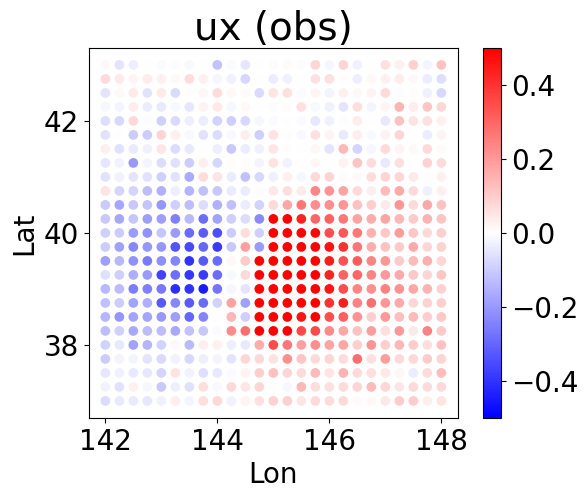

In [6]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=ux_obs, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("ux (obs)", fontsize=28)
fig.colorbar(im)
fig.show()

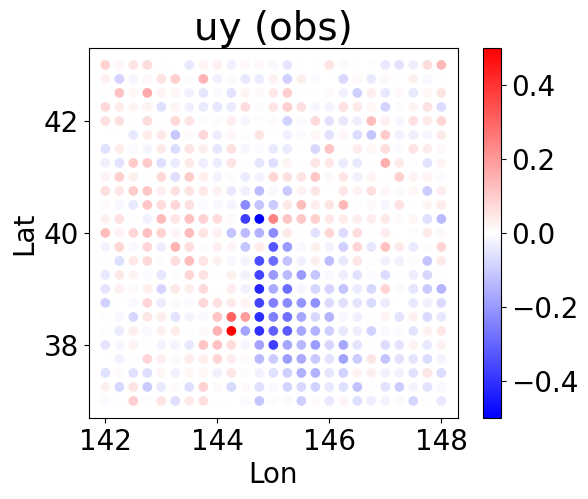

In [7]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uy_obs, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uy (obs)", fontsize=28)
fig.colorbar(im)
fig.show()

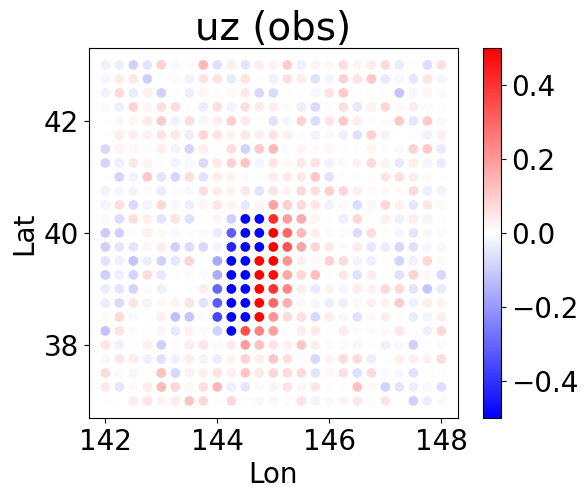

In [8]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uz_obs, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uz (obs)", fontsize=28)
fig.colorbar(im)
fig.show()

# Estimate `slip` using HMC-NUTS


The `HMC-NUTS` algorithm is used to obtain the posterior distribution of the fault parameters.
We use `numpyro`, a Bayesian modeling package written with PyTorch.
Please refer to [numpyro documentation](https://num.pyro.ai/en/stable/) for the usage.


\* HMC = Hamiltonian Monte Carlo

\* NUTS = No U-Turn Sampler



We adopt another simple scaling: for each parameter `p`, we set lower value `p1` and upper value `p2` in advance.

The MCMC algorithm samples the normalized parameter `q ∈ [0,1]`. It is then transformed to actual dimensions `p = p1 + (p2-p1)*q` and input to `okada.compute`.

In [9]:
# choose appropriate lower/upper calues
p1 = {
    "x_fault": jnp.array(x_fault-dX/10),
    "y_fault": jnp.array(y_fault-dY/10),
    "depth": jnp.array(0.0),
    "length": jnp.array(150.0),
    "width": jnp.array(25.0), 
    "strike": jnp.array(150.0),
    "dip": jnp.array(45.0), 
    "rake": jnp.array(225.0),
    "slip": jnp.array(3.0)
}
p2 = {
    "x_fault": jnp.array(x_fault+dX/10),
    "y_fault": jnp.array(y_fault+dY/10),
    "depth": jnp.array(10.0),
    "length": jnp.array(250.0),
    "width": jnp.array(75.0), 
    "strike": jnp.array(240.0),
    "dip": jnp.array(90.0), 
    "rake": jnp.array(315.0),
    "slip": jnp.array(10.0)
}

print(p1)
print(p2)

{'x_fault': Array(-37.9592547, dtype=float64), 'y_fault': Array(-8.82597908, dtype=float64), 'depth': Array(0., dtype=float64, weak_type=True), 'length': Array(150., dtype=float64, weak_type=True), 'width': Array(25., dtype=float64, weak_type=True), 'strike': Array(150., dtype=float64, weak_type=True), 'dip': Array(45., dtype=float64, weak_type=True), 'rake': Array(225., dtype=float64, weak_type=True), 'slip': Array(3., dtype=float64, weak_type=True)}
{'x_fault': Array(15.45453485, dtype=float64), 'y_fault': Array(58.23190031, dtype=float64), 'depth': Array(10., dtype=float64, weak_type=True), 'length': Array(250., dtype=float64, weak_type=True), 'width': Array(75., dtype=float64, weak_type=True), 'strike': Array(240., dtype=float64, weak_type=True), 'dip': Array(90., dtype=float64, weak_type=True), 'rake': Array(315., dtype=float64, weak_type=True), 'slip': Array(10., dtype=float64, weak_type=True)}


In [10]:
u_obs = jnp.stack([ux_obs, uy_obs, uz_obs])

X_obs_ = X_obs#.reshape(-1)
Y_obs_ = Y_obs#.reshape(-1)
u_obs_ = u_obs#.reshape(-1)

# define model
def model(X_obs_, Y_obs_, u_obs_):
    
    # prior.  A local dict: NUTS traces the model under jit, and writing the
    # traced values into a global would leak tracers out of the trace.
    params = {key: p1[key] + (p2[key] - p1[key]) * numpyro.sample(key, dist.Uniform(0.0, 1.0))
              for key in params_true}

    # model prediction
    ux_pred, uy_pred, uz_pred = okada.compute(coords, params, compute_strain=False, is_degree=True, fault_origin="topleft")
    u_pred = jnp.stack([ux_pred, uy_pred, uz_pred])

    # noise distribution 
    numpyro.sample("obs", dist.Normal(u_pred, 0.05), obs=u_obs_)

In [11]:
from jax import random
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

In [12]:
jax.clear_caches()
kernel = NUTS(model, step_size=1e-3, adapt_step_size=True)
# If GPU is used, num_samples=1000 takes ~ 1.5 min; num_samples=10000 takes ~ 5 min.
mcmc = MCMC(kernel, num_samples=10000, num_warmup=200)
mcmc.run(rng_key_, X_obs_, Y_obs_, u_obs_)
mcmc.print_summary()

sample: 100%|██████████| 10200/10200 [04:56<00:00, 34.38it/s, 23 steps of size 5.86e-02. acc. prob=0.91]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
     depth      0.01      0.00      0.01      0.01      0.02   5401.63      1.00
       dip      0.33      0.00      0.33      0.32      0.33   6926.05      1.00
    length      0.67      0.01      0.67      0.66      0.68  10480.44      1.00
      rake      0.50      0.00      0.50      0.50      0.50   3212.60      1.00
      slip      0.38      0.00      0.38      0.37      0.39  11570.58      1.00
    strike      0.44      0.00      0.44      0.43      0.44   3419.66      1.00
     width      0.41      0.01      0.41      0.40      0.42   9756.97      1.00
   x_fault      0.50      0.01      0.50      0.50      0.51   2917.16      1.00
   y_fault      0.50      0.00      0.50      0.49      0.51  11436.36      1.00

Number of divergences: 0


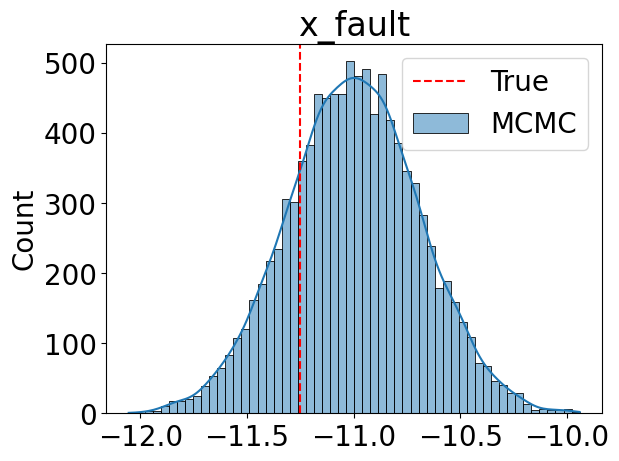

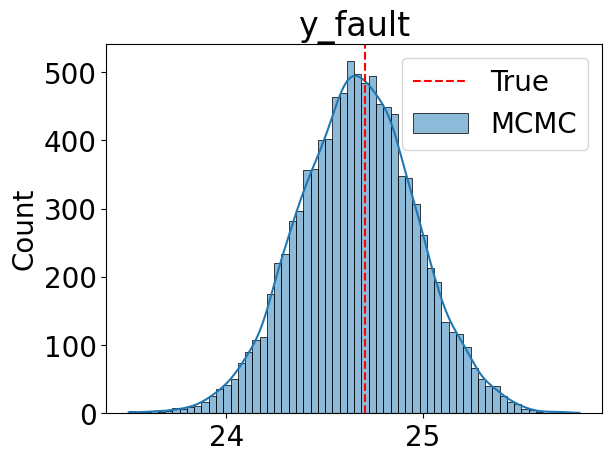

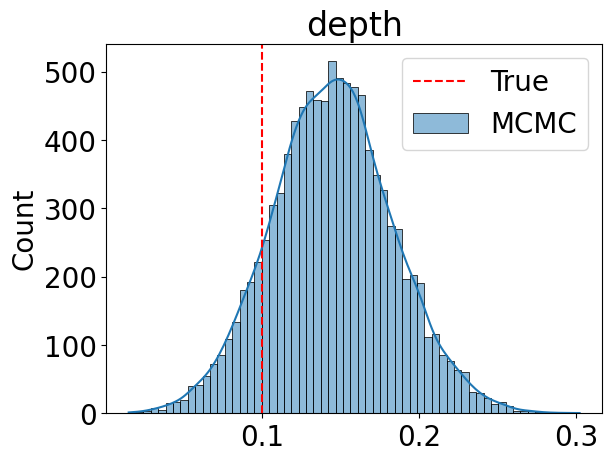

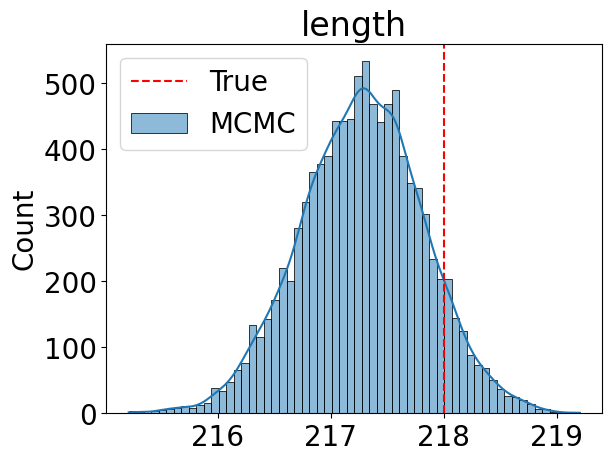

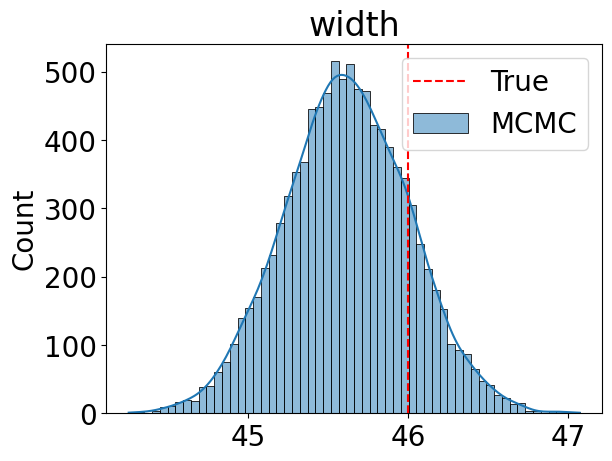

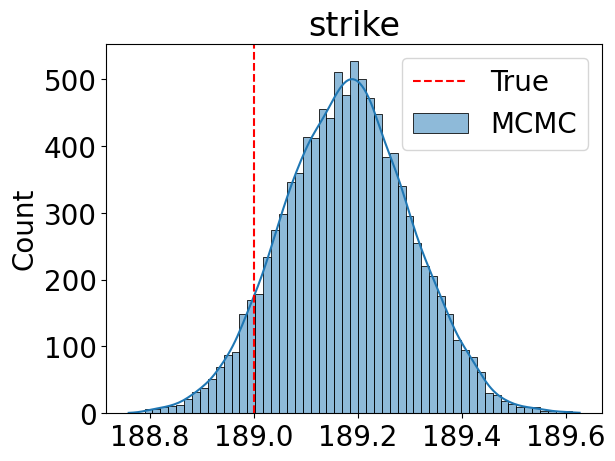

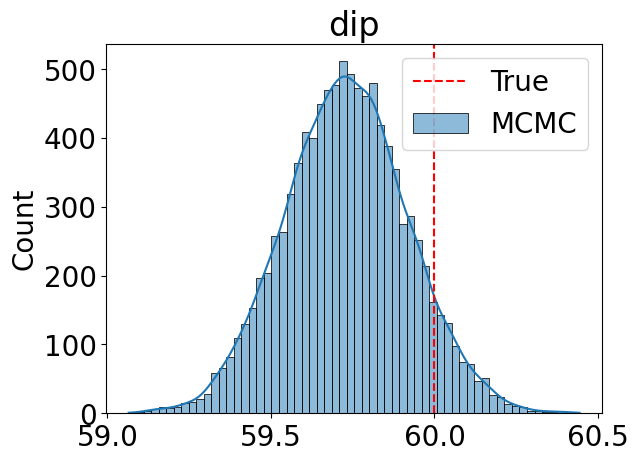

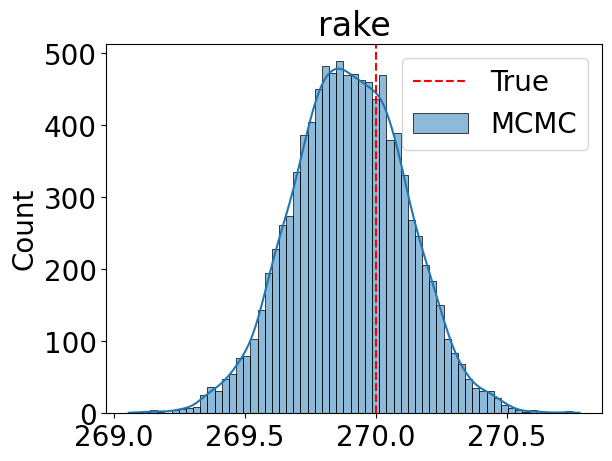

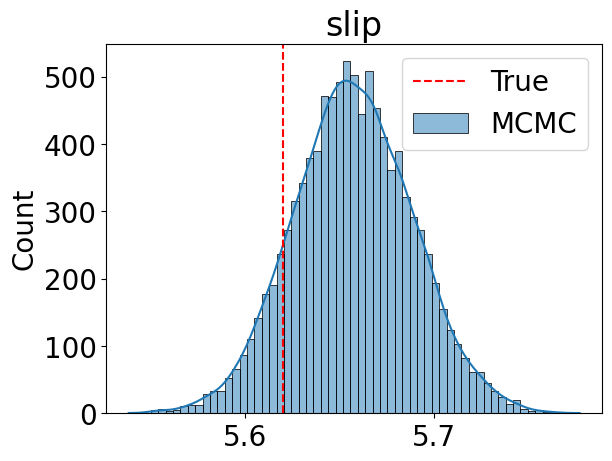

In [13]:
import seaborn as sns

posterior_samples = mcmc.get_samples()

for key in params_true: 
    p = p1[key] + (p2[key] - p1[key]) * posterior_samples[key]
    sns.histplot(p, kde=True, label="MCMC")
    plt.axvline(params_true[key].item(), color='red', linestyle='--', label='True')
    plt.legend()
    plt.title(key)
    plt.show()